# Declaration of Originality

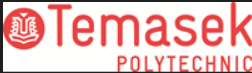

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  : Jared Nathaniel John (2401776F)
* Tutorial Group                : PC05
* Tutor						    : Dr Kian Eng Ong
* Submission Date               : 11 February 2026



**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import pandas as pd
import sklearn
from sklearn import datasets
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Business Understanding
<h2>Problem Statement</h2>
<h5>Cardiovascular diseases (CVDs) are the leading cause of death globally, taking an estimated 17.9 million lives each year. Early identification of individuals at high risk of heart disease is critical for medical professionals to implement preventative care, lifestyle changes, and medical interventions that can save lives and reduce the burden on healthcare systems.</h5>

## Project Objective
The primary goal of this project is to develop a predictive machine learning model that classifies whether an individual has a history of heart disease based on various health indicators. This is a classification task where the target variable is Heart_Disease (Yes/No).

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame FOR LOCALLY HOSTED
FILE_PATH = 'CVD_cleaned.csv'
df = pd.read_csv(FILE_PATH)
df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Good,Within the past year,No,No,No,No,Yes,No,Yes,Male,60-64,183.0,154.22,46.11,No,0.0,12.0,12.0,12.0
1,Good,Within the past year,Yes,No,No,No,No,No,Yes,Female,65-69,165.0,108.86,39.94,Yes,3.0,30.0,8.0,8.0
2,Fair,Within the past year,No,No,No,No,Yes,No,No,Female,65-69,163.0,72.57,27.46,Yes,0.0,12.0,12.0,4.0
3,Fair,Within the past year,No,No,Yes,No,No,No,No,Male,65-69,178.0,113.40,35.87,Yes,4.0,2.0,3.0,4.0
4,Excellent,Within the past 2 years,Yes,No,No,No,No,No,No,Female,70-74,152.0,52.16,22.46,No,0.0,30.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102946,Good,Within the past year,Yes,No,No,No,No,No,No,Male,60-64,163.0,65.32,24.72,No,8.0,4.0,4.0,2.0
102947,Very Good,5 or more years ago,No,No,No,No,No,No,No,Male,40-44,163.0,65.77,24.89,No,0.0,0.0,0.0,0.0
102948,Good,Within the past 5 years,Yes,No,No,No,No,No,No,Male,55-59,168.0,58.97,20.98,No,0.0,16.0,12.0,0.0
102949,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,168.0,81.65,29.05,No,4.0,30.0,8.0,0.0


In [20]:
from google.colab import drive   ## FOR COLAB
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
## Read *.csv file into pandas DataFrame  ~ FOR COLAB
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/CVD_cleaned.csv'
df = pd.read_csv(FILE_PATH)
df


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,168.0,81.65,29.05,No,4.0,30.0,8.0,0.0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180.0,69.85,21.48,No,8.0,15.0,60.0,4.0
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157.0,61.23,24.69,Yes,4.0,40.0,8.0,4.0
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183.0,79.38,23.73,No,3.0,30.0,12.0,0.0


## 2.2 Summary Statistics

In [3]:
## Shape of the Dataframe
df.shape

(102951, 19)

In [4]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102951 entries, 0 to 102950
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                102951 non-null  object 
 1   Checkup                       102951 non-null  object 
 2   Exercise                      102951 non-null  object 
 3   Heart_Disease                 102951 non-null  object 
 4   Skin_Cancer                   102951 non-null  object 
 5   Other_Cancer                  102951 non-null  object 
 6   Depression                    102951 non-null  object 
 7   Diabetes                      102951 non-null  object 
 8   Arthritis                     102951 non-null  object 
 9   Sex                           102951 non-null  object 
 10  Age_Category                  102951 non-null  object 
 11  Height_(cm)                   102951 non-null  float64
 12  Weight_(kg)                   102951 non-nul

In [5]:
# Check for any  missing values
df.isnull().sum()

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64

In [12]:
## Describe data distribution
df.describe(include = 'all')

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,102951,102951,102951,102951,102951,102951,102951,102951,102951,102951,102951,102951.000000,102951.000000,102951.000000,102951,102951.000000,102951.000000,102951.000000,102951.000000
unique,5,5,2,2,2,2,2,4,2,2,13,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN
top,Very Good,Within the past year,Yes,No,No,No,No,No,No,Female,65-69,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN
freq,36617,79796,79612,94708,92948,93063,82186,86460,69220,53355,11167,NaN,NaN,NaN,61091,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.664287,83.712597,28.650392,NaN,5.086779,29.756583,15.096191,6.300551
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.647121,21.457605,6.546627,NaN,8.199063,24.854970,14.904777,8.515978
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.000000,26.760000,12.120000,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163.000000,68.040000,24.210000,NaN,0.000000,12.000000,4.000000,2.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.000000,81.650000,27.440000,NaN,1.000000,30.000000,12.000000,4.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178.000000,95.250000,31.890000,NaN,6.000000,30.000000,20.000000,8.000000


## Summary of Data Understanding from Summary Statistics

The dataset comprises of **102951 entries** and **19 features**, with no missing values across any column. The features consist of **12 categorical** (object type) and **7 numerical** (float64 type) variables.

### Key observations include:

*   **Target Variable (`Heart_Disease`)**: It is a categorical variable with 'No' being the **dominating** class, indicating a significant **class imbalance** that will need to be addressed during model training.
*   **Categorical Features**: Variables like `General_Health`, `Checkup`, `Diabetes`, and `Age_Category` have multiple unique values beyond a simple binary choice. It was also noted that the `Diabetes` column, which is expected to be binary (Yes/No), currently has more than two unique values, suggesting the presence of abnormal values that will require **imputation or removal**. These categorical features will also require **one-hot encoding** to convert them into a numerical format suitable for machine learning models.
*   **Numerical Features**: Columns such as `Height_(cm)`, `Weight_(kg)`, and `BMI`, along with the consumption-related features (`Alcohol_Consumption`, `Fruit_Consumption`, etc.), show a wide range of values and potential **outliers**, as indicated by the spread between min/max and the quartile ranges. This suggests that  **outlier treatment** may be necessary for optimal model performance.




## 2.3 Data Visualization

### 2.3.1 Target Variable Analysis


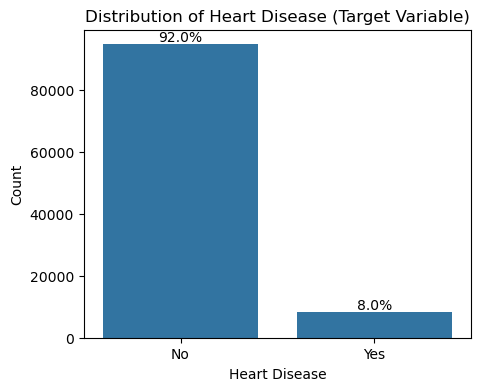

In [17]:
plt.figure(figsize=(5,4))

## Countplot
ax = sns.countplot(x='Heart_Disease', data=df)

# Calculate percentages
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percentage = count / total * 100
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.show()


#### **Target Variable Distribution: Heart Disease**

The distribution of the target variable, **Heart_Disease**, shows a clear class imbalance. The majority of individuals in the dataset do not have heart disease, while a significantly smaller proportion are labelled as having heart disease.

This imbalance indicates that the dataset is skewed towards the negative class. As a result, relying solely on **accuracy** as an evaluation metric may be misleading, since a model could achieve high accuracy by mainly predicting the majority class which is 'no' in this context.

**Implication for modelling:**  
To address this imbalance, evaluation metrics such as **recall**, **F1-score**, and **ROC-AUC** will be prioritised to better assess the model’s ability to correctly identify individuals at risk of heart disease. This is particularly important in a healthcare context, where false negatives may lead to missed early interventions.


### 2.3.2 Demographic Feature Distributions (Age and Sex)


#### Age Distribution


In [35]:
## Find the unique age groups in 'Age_Category' column
unique_ages = df['Age_Category'].unique()
print(unique_ages)

['60-64' '65-69' '70-74' '80+' '45-49' '55-59' '50-54' '75-79' '35-39'
 '30-34' '18-24' '40-44' '25-29']


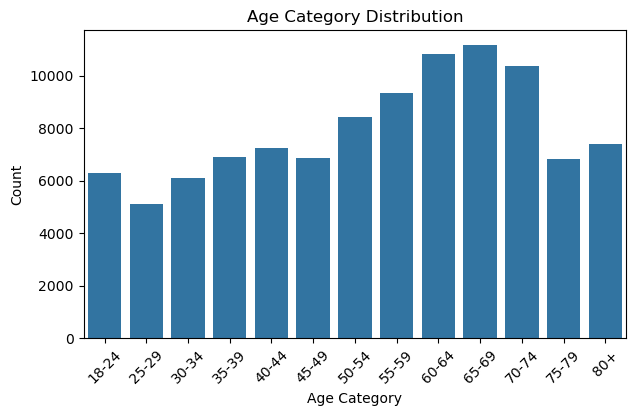

In [36]:
plt.figure(figsize=(7,4))
## Order of age groups before plotting
age_order =  ['18-24','25-29','30-34','35-39','40-44','45-49',
             '50-54','55-59','60-64','65-69','70-74','75-79','80+']
## Age Category Countplot with ordered ages
sns.countplot( 
    x='Age_Category',
    data=df,
    order=age_order
)

plt.title('Age Category Distribution')
plt.xlabel('Age Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### Sex Distribution


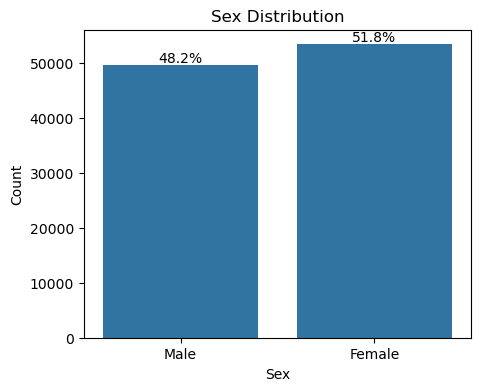

In [37]:
plt.figure(figsize=(5,4))
## Countplot for sex distribution
ax = sns.countplot(x='Sex', data=df)

## Find the percentages
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percentage = count / total * 100
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Sex Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

#### **Demographic Characteristics of the Dataset**

The age distribution indicates that most individuals in the dataset fall within the **middle to older age groups**, particularly between **50 and 69 years**. Younger age groups (18–29) are less represented, while the number of observations gradually decreases in the oldest age categories. This pattern is realistic for a cardiovascular health dataset, as the risk of heart disease generally increases with age.

The sex distribution is **well balanced**, with females accounting for approximately **51.8%** of the dataset and males **48.2%**. This near-equal representation helps minimise gender bias and ensures that the model can learn patterns effectively across both sexes.

**Implications for modelling:**  
Age will be treated as an important predictive feature, and its ordinal nature will be preserved during preprocessing to maintain the natural progression between age groups. The balanced sex distribution indicates that resampling is not required for this feature, and standard one-hot encoding can be applied without introducing bias.


### 2.3.3 Numerical Health Indicators (Distributions and Outlier Detection)


#### Distribution of Body Mass Index (BMI)


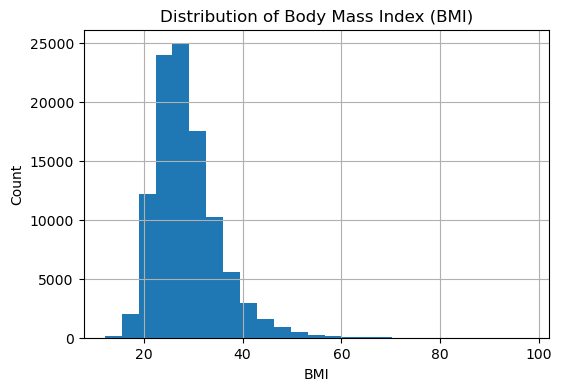

In [40]:
plt.figure(figsize=(5,3))

# Pandas histogram
df['BMI'].hist(bins=25, figsize=(6,4))

plt.title('Distribution of Body Mass Index (BMI)')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.grid(True) 
plt.show()

#### Outlier Analysis of All Numerical Features

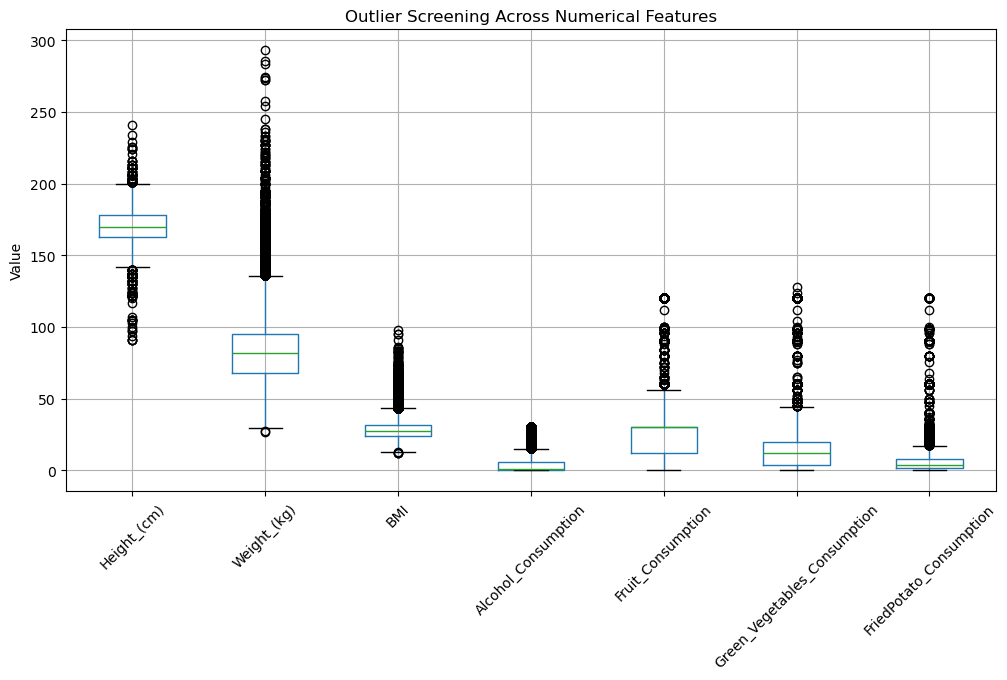

In [ ]:
# Select numerical columns 
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

## Plot boxplot of all numerical columns to identify  outliers
plt.figure(figsize=(12,6))
df[numerical_cols].boxplot()
plt.title('Outlier Screening Across Numerical Features')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.show()


#### **Numerical Health Indicators and Outlier Analysis**

The distribution of **Body Mass Index (BMI)** shows a right-skewed pattern, with most individuals clustered between approximately **20 and 35**. A smaller number of observations extend into much higher BMI values, indicating the presence of extreme but plausible cases. This reflects real-world health data, where obesity is less common but clinically important.

The outlier screening across all numerical features reveals that several variables contain extreme values. BMI and weight show some **extreme** noticeable high-end outliers, while lifestyle-related variables such as **alcohol consumption**, **fruit intake**, **green vegetable consumption**, and **fried potato consumption** also display wide variability and occasional extreme values. These values are not unexpected in self-reported health and lifestyle datasets and represent realistic differences in individual behaviour and health conditions rather than data errors.

**Implications for modelling:**  
The presence of skewed distributions and extreme values indicates that numerical features capture a wide range of health and lifestyle behaviours. These outliers will be retained to preserve real-world variability, as removing them will eliminate clinically important high-risk cases. The source of the dataset also clearly indicates that the data is **not syntheically generated** and is based on real data. Link = https://www.kaggle.com/datasets/alphiree/cardiovascular-diseases-risk-prediction-dataset , the data set description is in the about section(screenshot below).
Given the binary nature of the target variable(Heart_Disease), **logistic regression** is appropriate for this problem, as it is well-suited for classification tasks and provides interpretable results. In addition, tree-based models will also be considered due to their robustness to outliers and ability to capture non-linear relationships, allowing model performance to be balanced with interpretability and business needs.

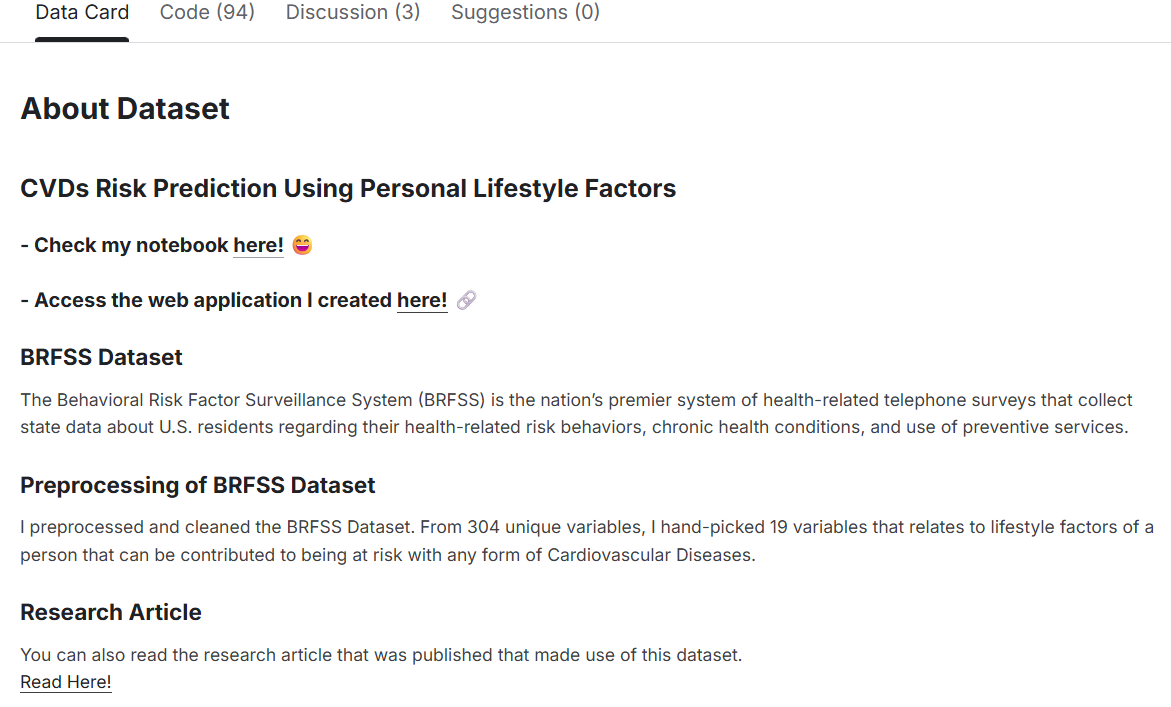

### 2.3.4 Target vs Key Predictive Features


#### Age and Cardiovascular Disease Risk


#### Body Mass Index and Cardiovascular Disease Risk


#### Lifestyle Factors and Cardiovascular Disease Risk


### 2.3.5 Lifestyle and Dietary Factors


### Alcohol Consumption Patterns


### Dietary Habits and Cardiovascular Disease Risk


### 2.3.6 Feature Relationships and Correlation Analysis


# 3. Data Preparation

## 3.1 Data Cleaning

In [14]:
## Clean data

## 3.2 Train-Test Split

In [9]:
## Split data into train set and test set


# 4. Modelling

### 4.2 Train Model

In [10]:
## Initialise and train model


# 5. Model Evaluation

In [11]:
## Evaluate model


In [ ]:
## New data

## Predict


## Iterative model development


In [ ]:
## Further feature engineering / feature selection